<a href="https://colab.research.google.com/github/julipolovinkina-hub/pract_programm/blob/main/laba3_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Задание task_03_04_10.
#
# Выполнил: Половинкина Ю. С.
# Группа: ЦИБ-251


import json


class IllegalArgumentError(ValueError):
    pass


def load_phonebook(filename):
    """Загрузить данные телефонной книги из json-файла 'filename'.

    Параметры:
        - filename (str): имя файла.

    Результат:
        - list of dict.

    Функция не обрабатывает исключения."""
    with open(filename, 'r', encoding='utf-8') as f:
        return json.load(f)


def save_phonebook(filename, phonebook):
    """Сохранить телефонную книгу 'phonebook' в json-файл 'filename'.

    Параметры:
        - filename (str): имя файла;
        - phonebook (list of dict): телефонная книга.

    Функция не обрабатывает исключения."""
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(phonebook, f, ensure_ascii=False, indent=2)


def search_by_name(phonebook, name):
    """Вернуть записи в телефонной книге, в имена которых входит 'name'
    (без учета регистра).

    Параметры:
        - phonebook (list of dict): телефонная книга;
        - name (str): имя контакта (не пустое).

    Результат:
        - list of dict.

    Исключения:
        - IllegalArgumentError: нарушение типа или содержимого 'name'.
    """
    if not isinstance(name, str) or not name.strip():
        raise IllegalArgumentError("Параметр 'name' должен быть непустой строкой")

    result = []
    name_lower = name.lower()

    for contact in phonebook:
        if name_lower in contact['имя'].lower():
            result.append(contact)

    return result


def search_by_phone(phonebook, phone_number):
    """Вернуть записи в телефонной книге, телефоны которых содержат
    'phone_number'.

    Параметры:
        - phonebook (list of dict): телефонная книга;
        - phone_number (str): номер телефона (не пустой).

    Результат:
        - list of dict.

    Исключения:
        - IllegalArgumentError: нарушение типа или содержимого 'phone_number'.
    """
    if not isinstance(phone_number, str) or not phone_number.strip():
        raise IllegalArgumentError("Параметр 'phone_number' должен быть непустой строкой")

    result = []

    for contact in phonebook:
        for phone in contact['телефоны']:
            if phone_number in phone['номер']:
                result.append(contact)
                break

    return result


def add_record(phonebook, name, phones):
    """Добавить в телефонную книгу запись с именем 'name' и списком
    телефонов 'phones'.

    Параметры:
        - phonebook (list of dict): телефонная книга;
        - name (str): имя (не пустое);
        - phones (list of dict): список телефонных номеров с описанием вида:
                                    {
                                        "описание": "мобильный",
                                        "номер": "+7111000043"
                                    }
                                 значения не должны быть пустыми.

    Результат:
        - phonebook (list of dict): телефонная книга.

    Исключения:
        - IllegalArgumentError:
          нарушение типа или содержимого 'name' или 'phones'.
    """
    if not isinstance(name, str) or not name.strip():
        raise IllegalArgumentError("Параметр 'name' должен быть непустой строкой")

    if not isinstance(phones, list):
        raise IllegalArgumentError("Параметр 'phones' должен быть списком")

    for phone in phones:
        if not isinstance(phone, dict):
            raise IllegalArgumentError("Каждый телефон должен быть словарем")
        if 'описание' not in phone or 'номер' not in phone:
            raise IllegalArgumentError("Телефон должен содержать ключи 'описание' и 'номер'")
        if not isinstance(phone['описание'], str) or not phone['описание'].strip():
            raise IllegalArgumentError("Поле 'описание' должно быть непустой строкой")
        if not isinstance(phone['номер'], str) or not phone['номер'].strip():
            raise IllegalArgumentError("Поле 'номер' должно быть непустой строкой")

    new_contact = {
        'имя': name,
        'телефоны': phones
    }

    phonebook.append(new_contact)

    return phonebook


def remove_name(phonebook, name):
    """Удалить из телефонной книги все контакты, содержащие 'name'
    (без учета регистра).

    Параметры:
        - phonebook (list of dict): телефонная книга;
        - name (str): имя (не пустое).

    Исключения:
        - IllegalArgumentError: нарушение типа или содержимого 'name'.
    """
    if not isinstance(name, str) or not name.strip():
        raise IllegalArgumentError("Параметр 'name' должен быть непустой строкой")

    name_lower = name.lower()

    i = 0
    while i < len(phonebook):
        if name_lower in phonebook[i]['имя'].lower():
            phonebook.pop(i)
        else:
            i += 1

    return phonebook  # ИСПРАВЛЕНО: добавлен возврат phonebook


def remove_phone(phonebook, phone_number):
    """Удалить из телефонной книги все телефоны, содержащие 'phone'.

    Параметры:
        - phonebook (list of dict): телефонная книга;
        - phone_number (str): номер телефона (не пустой).

    Результат:
        - phonebook (list of dict): телефонная книга.

    Исключения:
        - IllegalArgumentError: нарушение типа или содержимого 'phone_number'.
    """
    if not isinstance(phone_number, str) or not phone_number.strip():
        raise IllegalArgumentError("Параметр 'phone_number' должен быть непустой строкой")

    for contact in phonebook:
        i = 0
        while i < len(contact['телефоны']):
            if phone_number in contact['телефоны'][i]['номер']:
                contact['телефоны'].pop(i)
            else:
                i += 1

    return phonebook


def pretty_print(data):
    print(json.dumps(data, ensure_ascii=False, indent=2))


# Операции ниже выполняют тестирование реализованных функций
# Закомментируйте/раскомментируйте необходимые операции

filename = "phonebook.json"

phonebook = load_phonebook(filename)
# pretty_print(phonebook)

# Поиск
search_res = search_by_name(phonebook, "ВА")
# pretty_print(search_res)
assert len(search_res) == 3

search_res = search_by_phone(phonebook, "9")
# pretty_print(search_res)
assert len(search_res) == 2

# Добавление
assert len(search_by_name(phonebook, "Павлова Алиса")) == 0
phonebook = add_record(phonebook, "Павлова Алиса", [
    {
        "описание": "мобильный",
        "номер": "+7111000033"
    }
])
assert len(search_by_name(phonebook, "Павлова Алиса")) == 1

phonebook = add_record(phonebook, "Семенов Семен", [
    {
        "описание": "мобильный",
        "номер": "+7111000043"
    },
    {
        "описание": "мобильный 2",
        "номер": "+7222000333"
    }
])
assert len(search_by_name(phonebook, "Семенов Семен")) == 1

# Удаление
phonebook = remove_phone(phonebook, "33")
assert len(search_by_phone(phonebook, "7111000033")) == 0
assert len(search_by_phone(phonebook, "7222000333")) == 0

phonebook = remove_name(phonebook, "Семенов Семен")
assert len(search_by_name(phonebook, "Семен")) == 0

# pretty_print(phonebook)

# save_phonebook(filename, phonebook)

print("Основные операции работают успешно.")

Основные операции работают успешно.


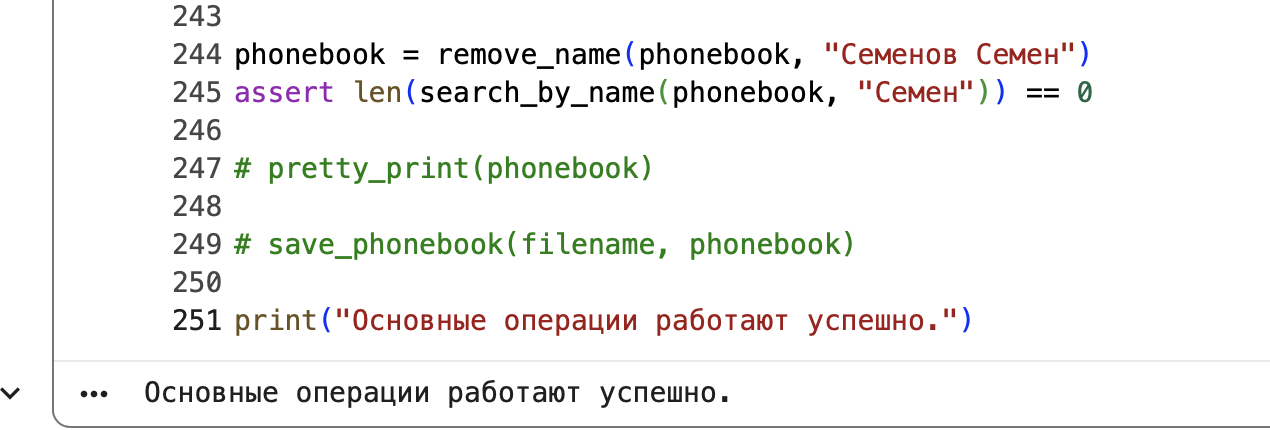

load_phonebook(filename) - загрузка данных из JSON-файла с использованием json.load() и кодировкой UTF-8.
save_phonebook(filename, phonebook) - сохранение справочника в JSON-файл через json.dump() с параметрами ensure_ascii=False (для кириллицы) и indent=2 (для красивого форматирования).
search_by_name(phonebook, name) - поиск контактов по подстроке в имени без учёта регистра (через .lower()). Валидация параметра name с выбросом IllegalArgumentError.
search_by_phone(phonebook, phone_number) - поиск контактов, у которых хотя бы один номер телефона содержит заданную подстроку. Валидация параметра phone_number.
add_record(phonebook, name, phones) - добавление новой записи с полной валидацией: проверка типа name, что phones - список словарей, наличие обязательных ключей 'описание' и 'номер', непустота значений.
remove_name(phonebook, name) - удаление всех контактов, имя которых содержит заданную подстроку. Использован цикл while с индексом для безопасного удаления элементов из списка. Функция возвращает изменённый справочник.
remove_phone(phonebook, phone_number) - удаление всех номеров, содержащих заданную подстроку, из каждого контакта. Также использован цикл while для безопасного удаления.